# NBA Points per Game Differential

The 2025-26 NBA regular season ended with teams overachieving, underachieving, and meeting expectations. The San Antonio Spurs and the Detroit Pistons took large leaps with 60+ win seasons, while the Indiana Pacers took a dramatic fall after appearing in the NBA finals in the season prior. Does a team's increase or decrease in points per game, compared to the previous season, reflect whether they had a good or bad season?

## Importing Packages and Gathering Raw Data

### Packages
- <span style="color:#4EC9B0">*leaguegamefinder*</span>, from nba_api - to gather raw nba data.
- <span style="color:#4EC9B0">*pandas*</span> - For easier data wrangling and cleaning.
- <span style="color:#4EC9B0">*matplotlib.pyplot*</span> - For visualizing data on a graph.
- <span style="color:#4EC9B0">*Figure and Axes*</span> - For type hinting variables of a function.
- <span style="color:#4EC9B0">*OffsetImage and AnnotationBbox*</span> - For plotting team logos on bar graph.
- <span style="color:#4EC9B0">*numpy*</span> - For properly injesting .png files before ploting.
- <span style="color:#4EC9B0">*Image*</span> - For altering the sizes of the team and league logo. 
- <span style="color:#4EC9B0">*os*</span> - For basic pathing to needed data.

### Gathering Data
The leaguegamefinder function is used to gather summarized game data, including teams playing, scores, field goals made, fouls, etc. I used the season_nullable and season_type_nullable arguments to retreieve all regular season game data from the 2024-25 and 2025-26 seasons. The function returned the data in a pandas dataframe. I wrote the data out to a csv, so that I could review the raw data.

In [ ]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Figure, Axes
import numpy as np
import os
from PIL import Image
from pathlib import Path

# Pull data from the 2024-2025 NBA season
games_25 = leaguegamefinder.LeagueGameFinder(season_nullable='2024-25', season_type_nullable='Regular Season')
# get data frame from returned list
df_25: pd.DataFrame = games_25.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
csv_dir = 'csvs'
df_25.to_csv(os.path.join(csv_dir,'season_raw_25.csv') ,index=False)


# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_25.to_csv(os.path.join(csv_dir,'season_raw_26.csv') ,index=False)

## Filtering Data

The dataframe returned provided more data than what was needed. The next step is to only take the columns of data that are needed to determine points per game between seasons. Pandas filtering was used to reduced the dataframe to have 'SEASON_ID', 'TEAM_ABBREVITAION', and 'PTS' (points). The value in the 'SEASON_ID' column isn't the most convient way to decipher what season the data comes from. It was converted to contain the full year the season started on and the last two digits of the next year the season ended on (YYYY-YY). The reduced data can viewed in the 'season_breakdown_YY' csv file found in the csv folder.

In [115]:
# Keep Only columns that you need for each respective Season
# 2024-25
team_stats_25 = df_25[['SEASON_ID','TEAM_ABBREVIATION', 'PTS']]
# Change Season ID Value
team_stats_25['SEASON_ID'] = '2024-25'
# Write to csv for easy viewing
team_stats_25.to_csv(os.path.join(csv_dir,'season_breakdown_25.csv'), index=False)

# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'PTS']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv(os.path.join(csv_dir,'season_breakdown_26.csv'), index=False)

## Aggregation of Data

Now that the data is reduced to just the needed columns, the data can now be aggregated to determine how many points each team scored during the entirety of the respective seasons. Pandas built-in aggregate function was used to group the data by the team 3-letter abbreviation. Then the mean of the points scored per team was easily calculated with the 'mean' argument in the aggregate function. Finally, the 'reset_index' method was used for reindexing. A csv of the aggregated data can be viewed in 'season_agg_YY' for easier understanding of how the dataframe changed.

In [117]:
# Aggregating the 2024-25 season data by grouping by teams. Should only by 30 rows of data for 30 teams
summary_25 = (
    team_stats_25.groupby('TEAM_ABBREVIATION') # Group by team abbreviations
    .agg(
        points=('PTS', 'mean'), # Quickly find the mean of points scored for each team
    )
).reset_index() # reindex the aggregated index.

# Repeating the same steps performed previously, but for the 2025-26 season.
summary_26 = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
    )
).reset_index()

# Writting aggregated and reindexed data into a csv for each viewing of how the data has changed
summary_25.to_csv(os.path.join(csv_dir,'season_agg_25.csv'), index=False)
summary_26.to_csv(os.path.join(csv_dir,'season_agg_26.csv'), index=False)

## Merge Data and Determine Point Differential

### Merging

To simplify the process of determining the differences in points and having one data source, merging the two dataframes into one dataframe was required. The 'SEASON_ID' field was dropped in filtering, and then the names of the columns were simplified. The 'points' column was renamed to have the year the respective seasons ended included, so that when the data is merged, it will be easier to decipher between the seasons. The two dataframes were merged via inner join based on the teams name. 

### Point differential

Once the data was merged into one dataframe, the differences in point per game average for each team could be determined. A new column, 'p_diff' (for point differential), was created. The 'p_diff' column is the negative of the points from the 2024-25 season subtracted by the points from the 2025-26 season. After the 'p_diff' values were calculated, the dataframe was resorted greatest to least 'p_diff' values. The first 5 rows of the merged data can be viewed below.

In [118]:
#print(summary_25.head())
#print(summary_26.head())

# Filter Data to just contain the Team Name and the Points
season_25_points = summary_25[['TEAM_ABBREVIATION', 'points']] # 2024-25 season
season_26_points = summary_26[['TEAM_ABBREVIATION', 'points']] # 2025-26 season
# Simplify the Column names
season_25_points.columns = ["teams", "points_25"]
season_26_points.columns = ["teams", "points_26"]

# Merge the two data frames with an inner join based on the team names
combine_season = pd.merge(season_25_points, season_26_points, how='inner', on=['teams'])

# Create new column with the differences between point averages of the '25 and '26 seasons
combine_season['p_diff'] = -(combine_season['points_25'] - combine_season['points_26'])

# Sort the data from greatest point average difference to least
combine_season = combine_season.sort_values('p_diff', ascending=False)
print(combine_season.head()) # for a quick peak at the data.

   teams   points_25   points_26     p_diff
3    CHA  105.097561  116.012195  10.914634
21   ORL  105.426829  115.743902  10.317073
15   MIA  110.597561  120.865854  10.268293
22   PHI  109.609756  115.878049   6.268293
26   SAS  113.926829  119.829268   5.902439


## Supporting Functions

### Plotting NBA Logo

This is a simple function that places the NBA logo next to the title of the Bar Chart below.

In [137]:
def plot_nba_logo(fig: Figure, ax: Axes):
    # Path to NBA logo
    logo_path = os.path.join('logos', 'NBA_logo.png')
    # Read image into Numpy array
    img = plt.imread(logo_path)
    # Adjust 'zoom' to scale your image up or down
    imagebox = OffsetImage(img, zoom=1)

    anno_box = AnnotationBbox(imagebox, xy=(0.225, 1.05), xycoords='axes fraction', 
                              box_alignment=(0, 1), frameon=False)
    ax.add_artist(anno_box)


### Adjusting Size of Team Logos

The NBA team logos PNG files, obtained from *www.sportslogos.net*, are too large to plot on the bar graph. The *adjust_logo* function takes the original image of team a logo and reduces the size of the image so that it can fit on the graph. The image is saved off in a different directory to be called on easier.

In [138]:
from PIL import Image
from pathlib import Path

def adjust_logo(logo_path: str, width:int = 50, height:int = 50)->OffsetImage:
    image_name = Path(logo_path).name
    img = Image.open(logo_path)
    # width, height = img.size
    img.thumbnail(size=(width,height))
    image_adj = os.path.join('logos',image_name)

    img.save(image_adj, optimize=True, quality=85)
    # logo_bytes = image_to_io(img)
    # Read image into Numpy array
    new_img = plt.imread(image_adj)
    # Adjust 'zoom' to scale your image up or down
    imagebox = OffsetImage(new_img)

    return imagebox

## Plotting Bar Graph

Now that the difference in team scoring average between seasons are calculated, it can now be plotted on a bar graph. Below you can see, in order of greatest to least, the bars of the teams that incresed in scoring are green and the teams that decreased are in red. The value of increase or decrease can be seen hovering where the bar ends for each respective team.

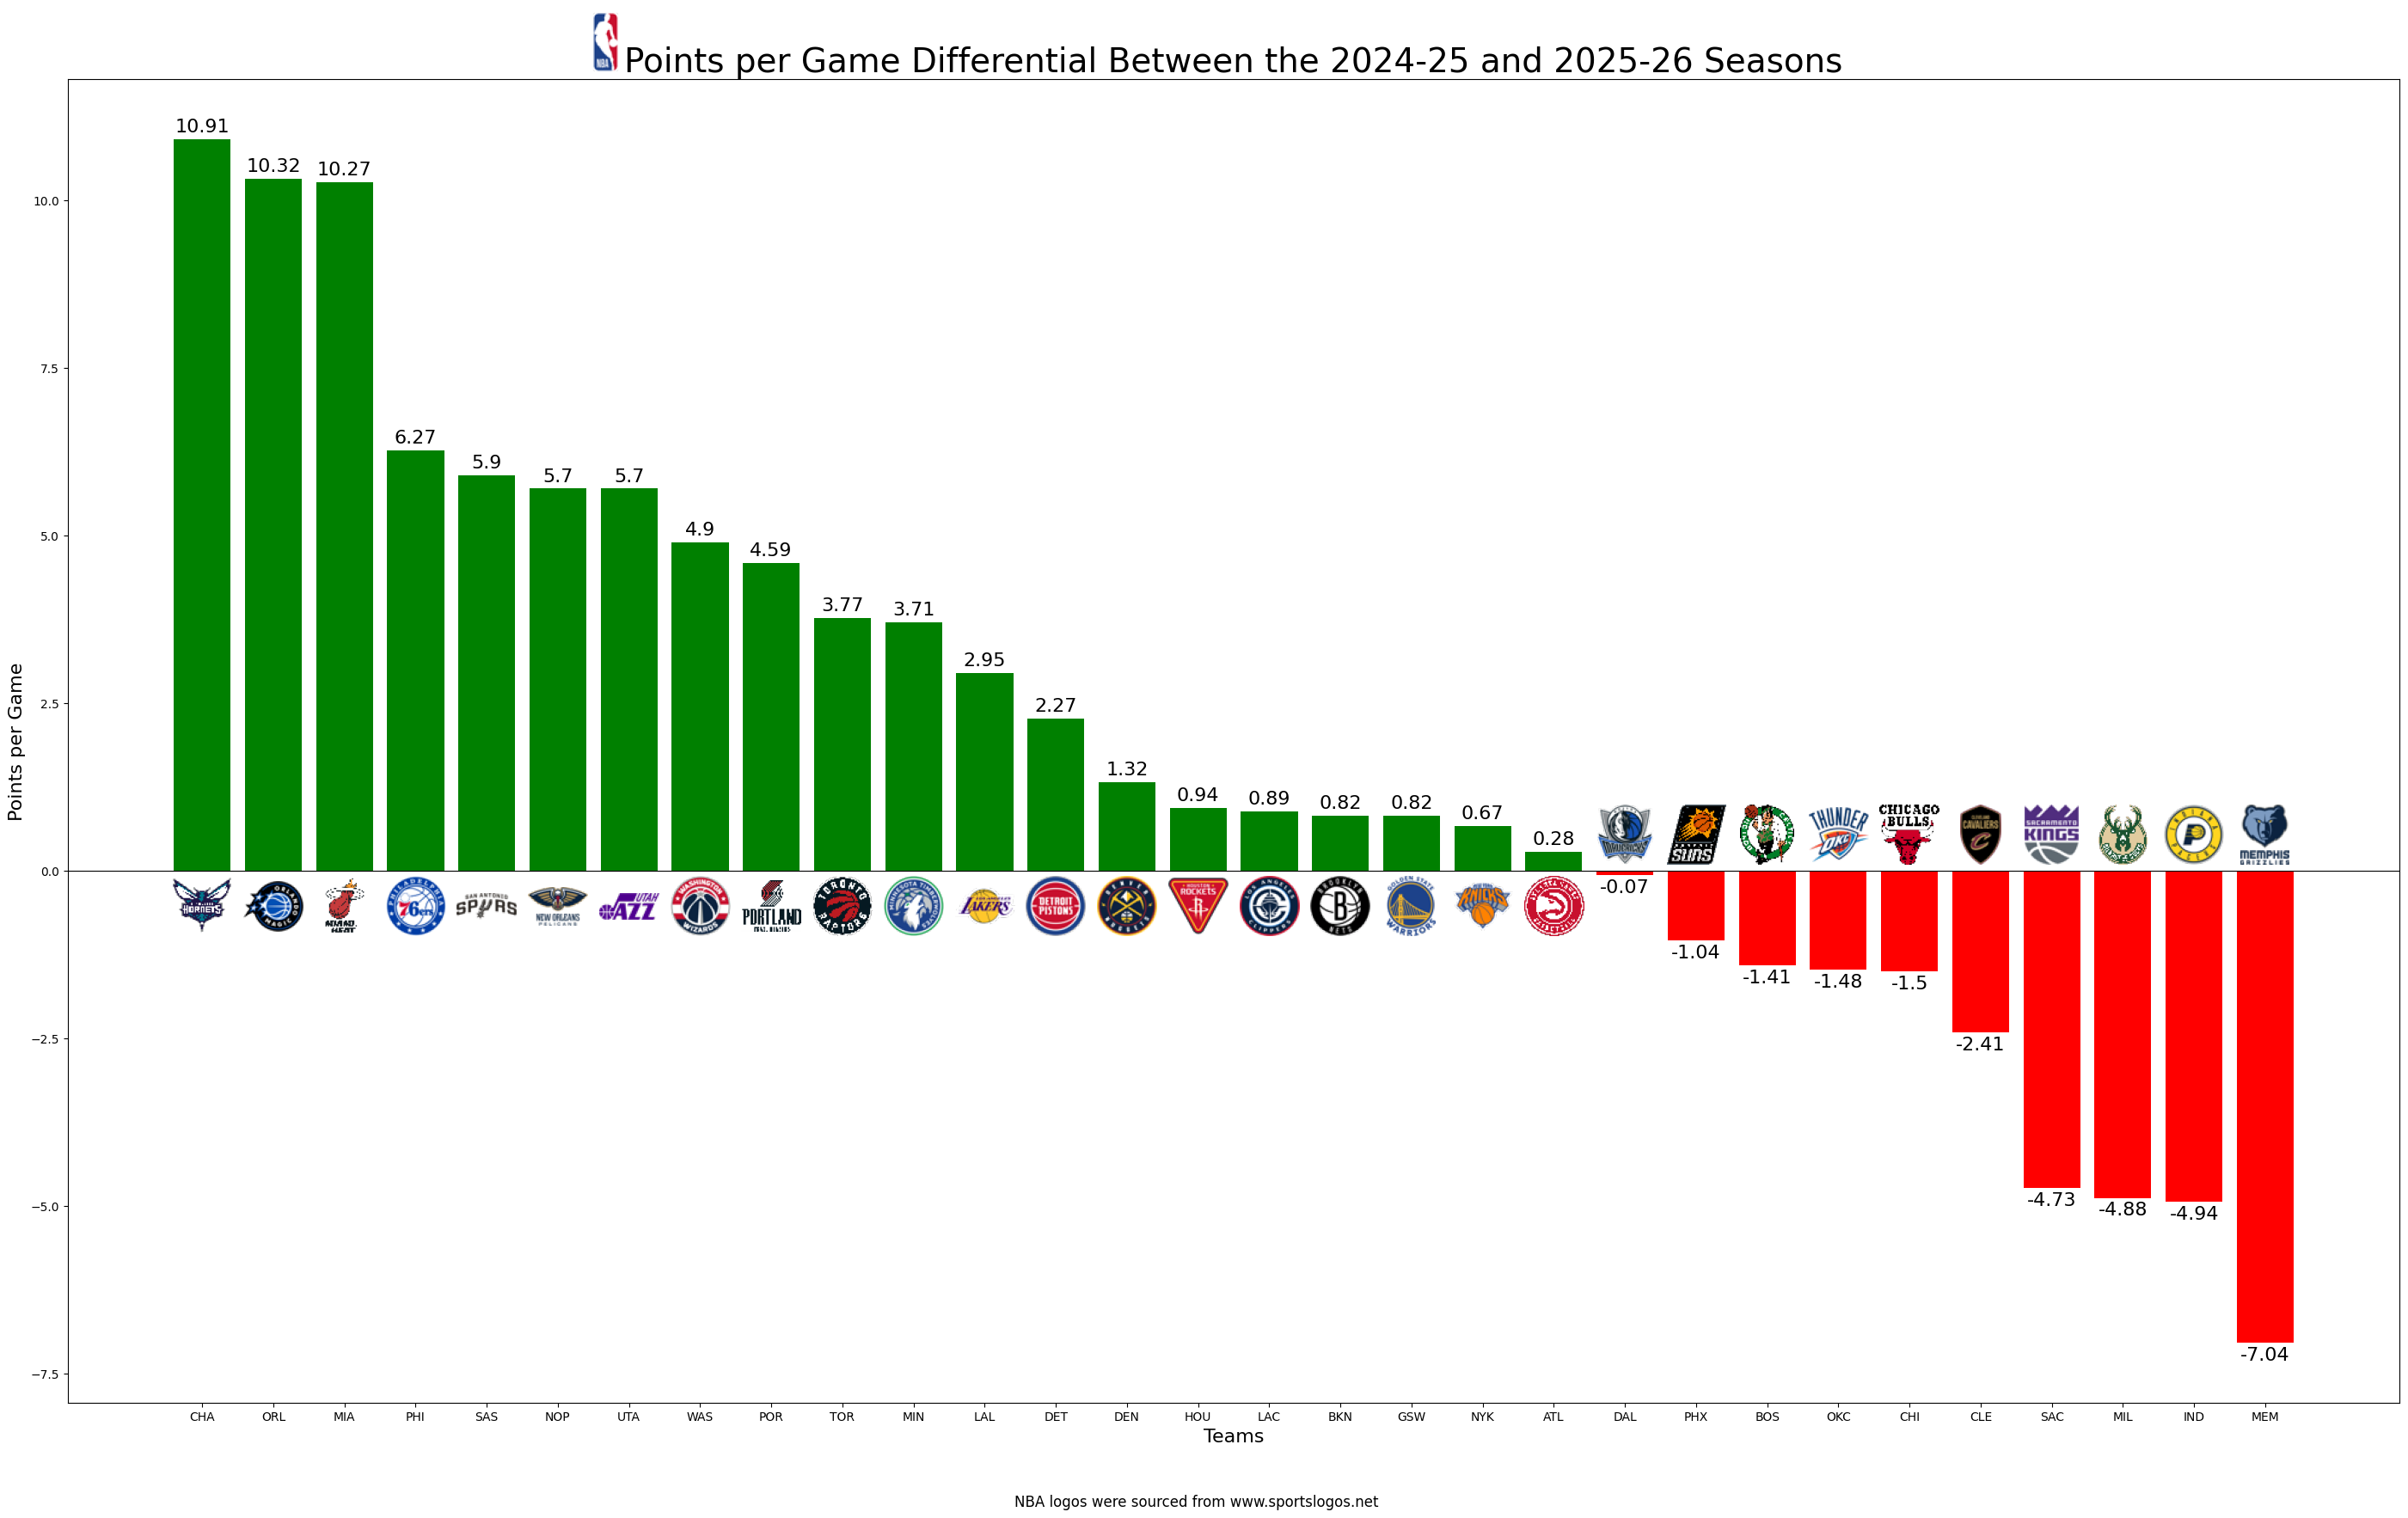

In [140]:
# create a list of the color red or green based on the value of th 'p_diff'. Positiver values will be green, negative will be red.
colors = ['red' if p < 0 else 'green' for p in combine_season['p_diff']]
# create a figure and axis to plot a bar graph
fig, ax = plt.subplots(figsize =(35, 20))
# create and object for when plotting bar graph so that it can be looped through later. Bar graph consist of team and 'p_diff' and ronuded 2 places.
bars = ax.bar(combine_season['teams'], round(combine_season['p_diff'], 2), color=colors, )

# Add Team Logos to the Bar Graph

# get tick labels of bar graph
bar_labels = ax.get_xticklabels()
# Loop through Bars and Labels
for bar, label in zip(bars, bar_labels):
    # Get Team Abbreviated Label
    team = label.get_text()
    # Get X Location
    x_pos = bar.get_x() + bar.get_width() / 2.0  # Center x-coordinate of the bar
    y_pos = 0                                    # Base of the bar (y=0)

    # Convert image to Offest Image
    # Get path to image based of of team name
    img_path = os.path.join('logos', 'logo_src', f'{team}_logo.png')
    # Read image into Numpy array
    # img = plt.imread(img_path)
    # Adjust 'zoom' to scale your image up or down
    imagebox = adjust_logo(img_path)
    # imagebox = OffsetImage(img)

    xybox_val = (0, -30) # Amount of pixels below bar to plot the team logo
    # If p_diff is a negative number, plot team logo above bar so that there is no clashing
    if bar.get_height() < 0:
        xybox_val = (0, 30)

    # Create the AnnotationBbox container
    # 'xybox=(0, -20)' shifts the image 20 points downwards below the base line
    ab = AnnotationBbox(
        imagebox, 
        xy=(x_pos, y_pos),
        xybox=xybox_val,
        xycoords='data',
        boxcoords='offset points',
        frameon=False  # Removes the border box around the image
    )
    
    # Add the image annotation to the axes
    ax.add_artist(ab)

plt.axhline(0, color='black', linewidth=0.8) # Add a line at y=0 for clarity
plt.title("Points per Game Differential Between the 2024-25 and 2025-26 Seasons", fontsize=28) # Title of graph
plt.ylabel("Points per Game", fontsize=16)
plt.xlabel("Teams", fontsize=16)
ax.bar_label(bars, padding=3, fontsize=16) # label p-diff values over or under each bar
plt.figtext(0.5, 0.05, "NBA logos were sourced from www.sportslogos.net", 
            wrap=True, horizontalalignment='center', fontsize=12)
plot_nba_logo(fig, ax) # plotting NBA logo next to title
plt.savefig('plots/Points_Diff.png') # save figure off as a .png
plt.show() # Display bar graph

## Conclusion

The Charlotte Hornets had the largest increase in point avergage from the 2024-25 season to the 2025-16 season. Despite the largest increase in points and the massive leap in wins the team accumulated during the second half of the season, the Hornets did not reach the playoffs. In fact the four teams (CHA, ORL, MIA, PHI) with the largest increase in points per game were all play-in teams in the Eastern conference. This goes to show that increasing the team's scoring does not necessarily translate into great outcomes.